In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from numpy.linalg import eig
import pandas as pd

#import matplotlib  
#matplotlib.use('Agg')  # Use a non-GUI backend

In [2]:
cat='C6'
path=f'C:/shehani/postdoc_work/ML_Diffusion/cal_md/new_cals/{cat}_rel/'
#path=f'C:/shehani/postdoc_work/ML_Diffusion/cal_md/new_cals/{cat}_rel/'

#df = pd.DataFrame(columns=['nrep', '#hops' 'Dnonhop_mean', 'Dnonhop_se', 'D_hop', 'Dtot'])

In [3]:
def oh_xyz(nrep, nsteps):
    #nrep = number of replicas
    #nsteps = number of steps in fs/MD_freq (ex: for 10 ps simulation with MD_freq=10, nsteps=10,000/10=1000)

    #extracting x,y, z cordinates from oh_id.dat files
    x_oh = np.zeros((nrep,nsteps))
    y_oh = np.zeros((nrep,nsteps))
    z_oh = np.zeros((nrep,nsteps))
    indx_oh= np.zeros((nrep,nsteps))

    for i in range(nrep):
        with open(path+ f'oh_id_{i+1}.dat', 'r') as oh_id:
            xyz= oh_id.readlines()[:nsteps]
            
            for j in range(len(xyz)):   
                indx_oh[i,j]=int(xyz[j].split()[1])
                x_oh[i,j]=float(xyz[j].split()[2])
                y_oh[i,j]=float(xyz[j].split()[3])
                z_oh[i,j]=float(xyz[j].split()[4])
                
    #dtime=  np.arange(0.01, (0.01*ndt+0.01), 0.01)
    return(x_oh, y_oh, z_oh, indx_oh)




In [4]:
nrep=1

nsteps=20000

x_oh, y_oh, z_oh, indx_oh= oh_xyz(nrep, nsteps)

In [21]:
dtime = np.zeros(nsteps)
D1x=np.zeros(nrep)
D1y=np.zeros(nrep)
D1=np.zeros(nrep)
rx=[]
ry=[]
rz=[]
t=[]
ax=[]
ay=[]
t_hop=[]
tau=[]
for ll in range(nrep):
    int_indx= indx_oh[ll,0]
    int_x= x_oh[ll,0]
    int_y= y_oh[ll,0]
    int_z= z_oh[ll,0]
    int_t=0
    hop=0
    for jj in range(nsteps):
        dtime[jj]= np.round(jj*0.01, 2)
        
        if indx_oh[ll,jj]==int_indx:
            pass
            #print('nonhop',ll, jj, indx_oh[ll,jj],dtime[jj], x_oh[ll,jj])
        else:
            hop=hop+1
            #t_hop.append(dtime[jj])
            rx.append((x_oh[ll,jj-1]-int_x)**2)
            ry.append((y_oh[ll,jj-1]-int_y)**2)
            t.append(dtime[jj-1]-int_t)
            #print('hop',ll, jj, indx_oh[ll,jj])
            #print(int_t, int_indx, int_x, int_y)
            #print(dtime[jj-1], indx_oh[ll,jj-1], x_oh[ll,jj-1], y_oh[ll,jj-1])     
            #print(t[-1], rx[-1], ry[-1])   
            ax.append((x_oh[ll,jj]-x_oh[ll,jj-1])**2)
            ay.append((y_oh[ll,jj]-y_oh[ll,jj-1])**2)
            #print(jj)

            if hop>1:
                #ax.append((x_oh[ll,jj]-x_oh[ll,jj-1])**2)
                #ay.append((y_oh[ll,jj]-y_oh[ll,jj-1])**2)
                #print(ll,jj,(x_oh[ll,jj]-x_oh[ll,jj-1])**2 )
                #print(x_oh[ll,jj],x_oh[ll,jj-1])
                #print(dtime[jj-1],int_t)
                t_hop.append(dtime[jj-1]-int_t)

            
            int_indx= indx_oh[ll,jj]
            int_x= x_oh[ll,jj]
            int_y= y_oh[ll,jj]
            int_z= z_oh[ll,jj]
            int_t=dtime[jj]
            #print(hop,int_t)

            #print(indx_oh[ll,jj], x_oh[ll,jj], x_oh[ll,jj-1], dtime[jj],int_t)
            
    #print(ll,hop)
    rx.append((x_oh[ll,-1]-int_x)**2)
    ry.append((y_oh[ll,-1]-int_y)**2)
    rz.append((z_oh[ll,-1]-int_z)**2)
    t.append(dtime[-1]-int_t)
    
    D1x[ll]=(np.mean(rx))/(2*np.mean(t))
    D1y[ll]=(np.mean(ry))/(2*np.mean(t))
    D1[ll]=(np.mean(rx)+np.mean(ry))/(4*np.mean(t))

dmean= np.mean(D1)
dstd= np.std(D1)
std_err= dstd/np.sqrt(nrep)

D2x=(np.mean(ax))/(2*np.mean(t_hop))
D2y=(np.mean(ay))/(2*np.mean(t_hop))
D2=(np.mean(ax)+np.mean(ay))/(4*np.mean(t_hop))
D=dmean+D2
                    
#print('nohops:',dmean, std_err)
#print('hops:',D2)
#print('Total:',D)
print(rx)
print(t)

[1.4749324501559216, 1.8639458443065595, 51.61128232121452, 23.445578163302084, 10.969068907004743, 2.168067715198561, 30.846382707224958, 0.2853183377379212, 8.737158116353296, 0.024183587145132773, 0.08512487791642268, 0.12550992536643973, 23.718086346835253, 0.3121827552582489, 66.3619798298648, 31.089888775678787, 0.05065543357246476, 0.5068228390803093, 0.1386986078876631, 0.5242909775043612, 12.892071276675347, 8.783193404939176, 28.045232321047486, 0.029717519111290547, 66.90243876675922, 69.26411211224043, 2.286094467148306, 1.4070396938639618, 0.4866534196781388, 0.17131272987633633, 28.51978062561745, 10.341152510323736]
[2.19, 3.74, 4.86, 5.550000000000001, 4.5, 2.4499999999999993, 3.7399999999999984, 0.639999999999997, 6.060000000000002, 3.5899999999999963, 0.5300000000000011, 4.140000000000001, 1.9399999999999977, 5.219999999999999, 8.450000000000003, 10.040000000000006, 5.8500000000000085, 3.200000000000003, 0.37999999999999545, 0.36999999999999034, 3.1099999999999994, 7.

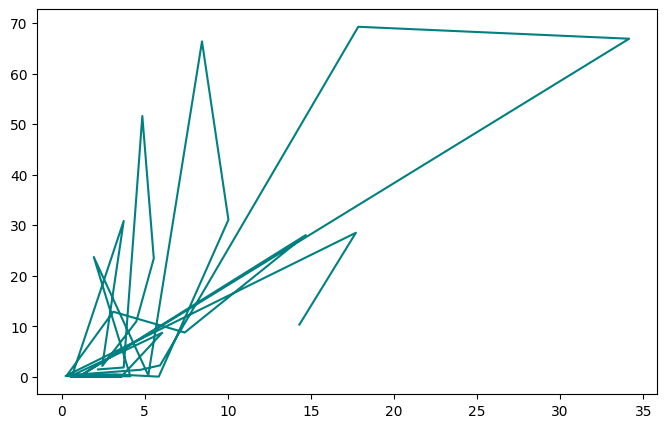

In [6]:
#plt.figure(figsize=(8,5))
#plt.plot(t, rx, color='teal')

In [7]:
len(t_hop)+nrep

31

In [8]:
dmean= np.mean(D1)
dstd= np.std(D1)
std_err= dstd/np.sqrt(nrep)
dmean, dstd, std_err

(0.9360888091833505, 0.0, 0.0)

In [9]:
c2=0.9627078511609803
c4= 0.8756260083700356
c6=0.738363956584734

In [10]:
np.mean(ax)

2.3487950648342184

In [11]:
np.mean(ay)

1.9659185909534935

In [12]:
len(ax)

31

In [13]:
len(ay)

31

In [14]:
len(t_hop)

30

In [15]:
D2x

0.1923350036713249

In [16]:
(np.mean(ax))

2.3487950648342184

In [17]:
np.mean(t_hop)

6.105999999999997

In [18]:
D2y

0.16098252464407914

In [19]:
D2

0.176658764157702